In [1]:
%load_ext autoreload
%autoreload 2
%load_ext Cython
%load_ext wurlitzer

import logging

# 1. Clear any pre-existing default handlers to prevent duplicate or missing logs
logger = logging.getLogger(__name__)
logger.setLevel(logging.INFO)
from stellarator_multichannel import StellaratorTransport
from objective2 import make_objective
from yancc_wrapper2 import yancc_data
import matplotlib.pyplot as plt
from desc.profiles import SplineProfile
from desc.plotting import plot_boozer_surface, plot_boundaries, plot_qs_error
from desc.plotting import plot_comparison
from desc.plotting import plot_1d
from desc.objectives import (
    AspectRatio,
    FixBoundaryR,
    FixBoundaryZ,
    FixCurrent,
    FixPsi,
    ForceBalance,
    LinearObjectiveFromUser,
    ObjectiveFunction,
    ObjectiveFromUser,
    RotationalTransform,
    Volume,
)
from desc.grid import Grid, LinearGrid
from desc.geometry import FourierRZToroidalSurface
from desc.equilibrium import Equilibrium, EquilibriaFamily
import desc.io
from desc import set_device
import desc
from yancc_wrapper2 import yancc_data
import yancc
import jax.numpy as jnp
import numpy as np
import jax
import manta as MaNTA
import os


Registering cpu implementation for operation get_solution
Registering gpu implementation for operation get_solution
Registering cpu implementation for operation get_adjoint_gradients
Registering gpu implementation for operation get_adjoint_gradients
Registering cpu implementation for operation get_g_val
Registering cpu implementation for operation run
Registering cpu implementation for operation run_ss
Using cache directory: /global/cfs/cdirs/mp217/eatocco/jax-cache
[CudaDevice(id=0), CudaDevice(id=1), CudaDevice(id=2), CudaDevice(id=3)]


In [2]:
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
os.environ["HDF5_USE_FILE_LOCKING"] = "FALSE"

fname = "stellarator_opt_amb"

eq_name = "eq_amb"
st_config = {
    "ParticleSourceCenter": 0.0,
    "ParticleSourceHeight": 0.1,
    "ParticleSourceWidth": 0.4,
    "NBICenter": 0.0,
    "NBIPower": 1.0,
    "NBIWidth": 0.3,
    "ECHCenter": 0.0,
    "ECHPower": 1.0,
    "ECHWidth": 0.3,
    "EdgeTemperature": 0.2,
    "EdgeDensity": 0.4,
    "n0": 0.5,
    "evolveDensity": True,
}

rho_upper = 1.0
rtol = 1e-2
atol = 1e-4
# nodes = [0.0,0.5, 0.75, 0.9, 1.0]
npoints = 4
degree = 4
base = 2.5
tau = 1.0
nodes = 1 - 1.0 / np.logspace(1, npoints - 1, base=base, num=npoints - 1)
nodes = np.concatenate(([0], nodes, [1]))
# # %%
solver_config = {
    "OutputFilename": "stellarator_opt_amb0",
    "Polynomial_degree": degree,
    "Grid_points": nodes,
    "Grid_size": len(nodes) - 1,
    "tau": tau,
    "Lower_boundary": 0.0,
    "Upper_boundary": rho_upper,
    "Relative_tolerance": rtol,
    "Absolute_tolerance": [atol],
    "delta_t": 1.0,
    "initialTimestep": 1e-4,
    "MinStepSize": 1e-9,
    "SteadyStateTolerance": 1e-3,
    "AggressiveTimesteps": False,
    "WriteDatFile": True,
    "zeroFlux": True,
    "solveAdjoint": False,
    "PseudoTransientSERRate": 2.0,
}


config = {
    "Stellarator": st_config,
    "Solver": solver_config,
}


points = MaNTA.getNodes(
    nodes,
    solver_config["Polynomial_degree"],
)

yancc_rho = jnp.array(points)

yancc_rho = jnp.array(points)
yancc_ntheta = 17
yancc_nzeta = 25

yancc_res = {"na": 43, "nx": 7}


In [3]:

pressure_rho = jnp.concatenate([jnp.zeros(1), yancc_rho, jnp.ones(1)])
desc_pressure = SplineProfile(jnp.zeros_like(pressure_rho), pressure_rho)

surf = FourierRZToroidalSurface(
    R_lmn=[1, 0.125, 0.1],
    Z_lmn=[-0.125, -0.1],
    modes_R=[[0, 0], [1, 0], [0, 1]],
    modes_Z=[[-1, 0], [0, -1]],
    NFP=4,
)
# create initial equilibrium. Psi chosen to give B ~ 1 T. Could also give profiles here,
# default is zero pressure and zero current
eq = Equilibrium(M=4, N=4, Psi=0.1, surface=surf, pressure=desc_pressure)
# this is usually all you need to solve a fixed boundary equilibrium
eq = eq.solve(x_scale="ess")[0]
# print(pressure_rho)
eqs = EquilibriaFamily(eq)
# eq = desc.io.load("eq_self_consistent_pressure.h5")
# desc_pressure = eq.get_profile('p')
eq_init = eq.copy()

V0 = eq.compute("V")["V"]
# yancc_wrapper = yancc_data.from_eq(points, grid = yancc_grid,rho = yancc_rho, Density=Density, eq=eq_init, nt = yancc_ntheta, nz = yancc_nzeta)
yancc_wrapper = yancc_data.from_eq(
    points, eq=eq_init, nt=yancc_ntheta, nz=yancc_nzeta, **yancc_res
)
## %%


Building objective: force
Precomputing transforms
Building objective: lcfs R
Building objective: lcfs Z
Building objective: fixed Psi
Building objective: fixed pressure
Building objective: fixed current
Building objective: fixed sheet current
Building objective: self_consistency R
Building objective: self_consistency Z
Building objective: lambda gauge
Building objective: axis R self consistency
Building objective: axis Z self consistency
Number of parameters: 120
Number of objectives: 850

Starting optimization
Using method: lsq-exact
Optimization terminated successfully.
`ftol` condition satisfied. (ftol=1.00e-02)
         Current function value: 7.266e-08
         Total delta_x: 1.735e-01
         Iterations: 7
         Function evaluations: 10
         Jacobian evaluations: 8
                                                                 Start  -->   End
Total (sum of squares):                                      5.010e-02  -->   7.266e-08, 
Maximum absolute Force error:         

In [ ]:
st = StellaratorTransport(config, yancc_wrapper=yancc_wrapper)
st.run()

/global/u2/e/eatocco/projects/MaNTA/python-physics/stellarator/config.py:64: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  self.constants = PlasmaConstants(ion_species, **constant_args)


Using batch size 0
configuring
Successfully created StellaratorTransport object


In [ ]:

plt.plot(points, 2.0 / 3.0 * st.InitialValue(0, points) / yancc_wrapper.Vp)  # %%


solver_config = {
    "OutputFilename": fname,
    "RestartFile": "stellarator_opt_amb0.restart.nc",
    "Polynomial_degree": degree,
    "Grid_points": nodes,
    "Grid_size": len(nodes) - 1,
    "tau": tau,
    "Lower_boundary": 0.0,
    "Upper_boundary": rho_upper,
    "Relative_tolerance": rtol,
    "Absolute_tolerance": [atol],
    "delta_t": 1.0,
    "initialTimestep": 1e-2,
    "MinStepSize": 1e-10,
    "restart": True,
    "zeroFlux": True,
    "SteadyStateTolerance": 1e-3,
    "PseudoTransientSERRate": 2.0,
}

config = {
    "Stellarator": st_config,
    "Solver": solver_config,
}
pi = []
fig, ax = plt.subplots()
eq2 = eq.copy()
fam2 = EquilibriaFamily(eq2)
niters = 2
for k in range(niters):
    eq2 = eq2.copy()

    fig, ax = plot_1d(eq2, "pressure", label="DESC " + str(k), ax=ax)

    yancc_wrapper = yancc_data.from_eq(
        points, eq=eq2, nt=yancc_ntheta, nz=yancc_nzeta, **yancc_res
    )
    pressure_rho = jnp.concatenate([jnp.zeros(1), yancc_rho, jnp.ones(1)])
    st = StellaratorTransport(config, yancc_wrapper=yancc_wrapper)
    st.run()

    pi = st.getPressure()
    pi_manta = jnp.concatenate([jnp.array([pi[0]]), pi, jnp.zeros(1)])
    ax.plot(pressure_rho, pi_manta, label="MANTA" + str(k))
    eq2.pressure = SplineProfile(pi_manta, pressure_rho)
    # fit the current profile to a power series, with c_0=c_1=0
    # XX = np.fliplr(np.vander(rho, eq2.L + 1)[:, :-2])
    # eq2.c_l = np.pad(np.linalg.lstsq(XX, current, rcond=None)[0], (2, 0))
    # re-solve the equilibrium
    eq2, _ = eq2.solve(objective="force", optimizer="lsq-exact", verbose=3)
    fam2.append(eq2)
    eqs.append(eq2)
eq_self_consistent = eq2.copy()

ax.legend()
fig.savefig("initial_self_consistent_pressure.png")
# %%

plot_comparison(eqs=[eq_init, eq2], labels=["Initial", "self-consistent"])
eq = eq2.copy()

Initializing yancc wrapper
Normalizing time = 0.10942367855611158
yancc_wrapper initialized successfully with resolution na=45, nx=5.
Using batch size 0
configuring
Successfully created StellaratorTransport object
Building objective: force
Precomputing transforms
Timer: Precomputing transforms = 109 ms
Timer: Objective build = 124 ms
Building objective: lcfs R
Building objective: lcfs Z
Building objective: fixed Psi
Building objective: fixed pressure
Building objective: fixed current
Building objective: fixed sheet current
Building objective: self_consistency R
Building objective: self_consistency Z
Building objective: lambda gauge
Building objective: axis R self consistency
Building objective: axis Z self consistency
Timer: Objective build = 157 ms
Timer: LinearConstraintProjection build = 1.97 sec
Number of parameters: 120
Number of objectives: 850
Timer: Initializing the optimization = 2.26 sec

Starting optimization
Using method: lsq-exact
Solver options:
--------------------------

delta t= 0.0001
Building objective: my mirror ratio
Building objective: volume
Precomputing transforms
Building objective: Custom
yancc_wrapper initialized successfully with resolution na=43, nx=7.


/global/u2/e/eatocco/projects/MaNTA/python-physics/stellarator/config.py:64: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  self.constants = PlasmaConstants(ion_species, **constant_args)


Using batch size 0
configuring
Successfully created StellaratorTransport object
------------ STORED ENERGY ----------------
JitTracer(float32[1])
-------------------------------------------
------------TOTAL PRESSURE ERROR-----------
JitTracer(float64[20])
-------------------------------------------


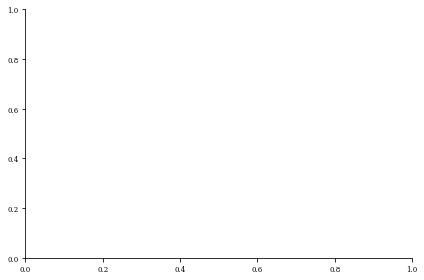

In [4]:
# %%



# %%


# %%
solver_config = {
    "OutputFilename": fname,
    "Polynomial_degree": degree,
    "Grid_points": nodes,
    "Grid_size": len(nodes) - 1,
    "tau": tau,
    "Lower_boundary": 0.0,
    "Upper_boundary": rho_upper,
    "Relative_tolerance": rtol,
    "Absolute_tolerance": [atol],
    "delta_t": 1.0,
    "initialTimestep": 1e-4,
    "MinStepSize": 1e-10,
    "WriteDatFile": True, 
    "restart": True,
    "zeroFlux": True,
    "SteadyStateTolerance": 2e-3,
    "PseudoTransientSERFloor": 2.0,
}
config = {
    "Stellarator": st_config,
    "Solver": solver_config,
}

manta_objective = make_objective(config, yancc_res=yancc_res)

# def manta_yancc_fun(fields, grid, Vprime):

#     stored_energy, pressure = Objective(fields, grid, Vprime)

#     return stored_energy, pressure


def objective_from_user_fun(grid, data):
    # note: don't change the signature to this function
    yancc_dat = {
        "B_sup_t": data["B^theta"],
        "B_sup_z": data["B^zeta"],
        "B_sub_t": data["B_theta"],
        "B_sub_z": data["B_zeta"],
        "Bmag": data["|B|"],
        "dBdt": data["|B|_t"],
        "dBdz": data["|B|_z"],
        "sqrtg": data["sqrt(g)"],
    }

    yancc_dat = {
        key: grid.meshgrid_reshape(val, "rtz") for key, val in yancc_dat.items()
    }

    yancc_dat["Psi"] = grid.compress(
        data["Psi"] / grid.nodes[:, 0] ** 2, surface_label="rho"
    )
    yancc_dat["a_minor"] = jnp.full(grid.num_rho, data["a"])
    yancc_dat["R_major"] = jnp.full(grid.num_rho, data["R0"])
    yancc_dat["iota"] = grid.compress(data["iota"], surface_label="rho")
    yancc_dat["rho"] = grid.compress(grid.nodes[:, 0], surface_label="rho")

    V = grid.compress(data["V(r)"])
    V_r = grid.compress(data["V_r(r)"])
    V_rr = grid.compress(data["V_rr(r)"])
    Vp = V_r / V[-1]
    Vpp = V_rr / V[-1]

    fields = jax.vmap(lambda d: yancc.field.Field(**d, NFP=grid.NFP))(yancc_dat)

    desc_pressure = grid.compress(data["p"], surface_label="rho")

    stored_energy, manta_pressure = manta_objective((fields, Vp, Vpp), grid)
    print("------------ STORED ENERGY ----------------")
    print(stored_energy)
    print("-------------------------------------------")

    # not sure if the sign makes the difference here
    pressure_error = manta_pressure - desc_pressure

    print("------------TOTAL PRESSURE ERROR-----------")
    print(pressure_error)
    print("-------------------------------------------")

    # optimization is easiest for least squares objectives, so instead of maximizing
    # stored energy we minimize 1/stored_energy^2 (the squaring happens later)
    return 1 / stored_energy  # jnp.append(pressure_error, 1 / stored_energy)


yancc_desc_grid = yancc_wrapper.grid

# domain_boundary_rho = rho_from_normalized_volume(0.9)
domain_boundary_rho = 1.0


def pressure_constraint_fun(params):
    # function to fix dp/dr=0 at axis and p=0 at edge
    # can modify this for other BC (eg fix p at rho=0.8)
    p_l = params["p_l"]
    dp0 = desc_pressure(Grid(jnp.zeros((1, 3)), jitable=True), p_l, dr=1)
    p1 = desc_pressure(
        Grid(jnp.zeros((1, 3)).at[0, 0].set(domain_boundary_rho), jitable=True), p_l
    )
    return jnp.array([dp0, p1]).squeeze()


pi_edge = (
    st_config["EdgeTemperature"]
    * st_config["EdgeDensity"]
    * 1e20
    * 1000
    * 1.6e-19
)
pressure_constraint_target = jnp.array([0.0, pi_edge])


# Mirror ratio, manually computed from "|B|"
def fun_mirror_ratio(grid, data):
    # alternatively, "mirror ratio" is something that can be computed in the data index
    # directly (see List of Variables docs), so can replace entirety of the above function code with this return statement
    return grid.compress(data["mirror ratio"])
    # or can just use GenericObjective(f="mirror ratio", thing=eq) or the already-existing objective, MirrorRatio(eq)


obj_mirror_ratio = ObjectiveFromUser(
    fun=fun_mirror_ratio,
    thing=eq,
    grid=yancc_desc_grid,
    bounds=(0.0, 0.3),
    weight=2.0,
    name="my mirror ratio",
)


# pressure_constraint_target = jnp.array([0.0, st.getPressure([0.9])[0]])

# %%

# other objectives are non-dimensionalized, so weights should account for that
# and handle relative weighting, this will likely need trial and error
# pressure_error_weight = jnp.full(yancc_desc_grid.num_rho, 1e-5)

# pressure_error_weight = jnp.full(yancc_desc_grid.num_rho, 2e-6)
stored_energy_weight = 1.0
# jnp.append(stored_energy_weight)
objective_from_user_weight = stored_energy_weight
fig, ax = plt.subplots()
max_it = 6

eqfam = EquilibriaFamily(eq)
# ks = [1, 2, eq.M + 1]
# for k in ks:
# print("\n==================================")
# print("Optimizing boundary modes M,N <= {}".format(k))
# print("====================================")
#
objectives = [
    # AspectRatio(eq=eq, target=6, weight=10),
    obj_mirror_ratio,
    Volume(eq=eqfam[-1], target=V0, weight=10.0),
    # RotationalTransform(eq=eq, target=0.42, weight=10),
    ObjectiveFromUser(
        objective_from_user_fun,
        eqfam[-1],
        target=0,
        weight=objective_from_user_weight,
        grid=yancc_desc_grid,
        deriv_mode="fwd",
        # need this assuming manta only has vjp, if using jvp switch to fwd
    ),
]

objective = ObjectiveFunction(objectives)
objective.build(use_jit=False)


# R_modes = np.vstack(
#     (
#         [0, 0, 0],
#         eq.surface.R_basis.modes[
#             np.max(np.abs(eq.surface.R_basis.modes), 1) > k, :
#         ],
#     )
# )
# Z_modes = eq.surface.Z_basis.modes[
#     np.max(np.abs(eq.surface.Z_basis.modes), 1) > k, :
# ]

In [ ]:
constraints = [
    ForceBalance(eq=eq),  # J x B - grad(p) = 0
    # fix zero current, eventually should use real bootstrap
    FixCurrent(eq=eq),
    # FixBoundaryR(eq=eqfam[-1], modes=R_modes),
    # FixBoundaryZ(eq=eqfam[-1odule], modes=Z_modes),
    FixPsi(eq=eq),  # fix total magnetic flux
    LinearObjectiveFromUser(
        pressure_constraint_fun, eq, target=pressure_constraint_target
    ),
]
# print(objective.jac_scaled(objective.x(eq)))
eq, info_out = eq.optimize(
    objective=objective,
    constraints=constraints,
    optimizer="proximal-lsq-exact",
    x_scale="ess",
    maxiter=max_it,
    ftol=1e-3,  # stopping tolerance on the function value
    xtol=1e-6,  # stopping tolerance on the step size
    gtol=1e-6,  # stopping tolerance on the gradient
    options={
        "initial_trust_radius": 0.005,
        # "perturb_options": {"order": 2, "verbose": 3},  # use 2nd-order perturbations
        #     # "solve_options": {
        #     #     "ftol": 5e-3,
        #     #     "xtol": 1e-6,
        #     #     "gtol": 1e-6,
        #     #     "verbose": 3,
        # },  # for equilibrium subproblem
    },
    verbose=3,
    copy=True,
)

Building objective: force
Precomputing transforms
Timer: Precomputing transforms = 109 ms
Timer: Objective build = 122 ms
Timer: Objective build = 1.87 ms
Timer: Eq Update LinearConstraintProjection build = 63.4 ms
Timer: Proximal projection build = 3.24 sec
Building objective: fixed current
Building objective: fixed Psi
Building objective: custom linear
Timer: Objective build = 1.98 sec
Timer: LinearConstraintProjection build = 1.66 sec
Number of parameters: 101
Number of objectives: 22
Timer: Initializing the optimization = 7.56 sec

Starting optimization
Using method: proximal-lsq-exact
yancc_wrapper initialized successfully with resolution na=43, nx=7.


/global/u2/e/eatocco/projects/MaNTA/python-physics/stellarator/config.py:64: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  self.constants = PlasmaConstants(ion_species, **constant_args)


Using batch size 0
configuring
Successfully created StellaratorTransport object


In [ ]:

# %%
eqfam.append(eq.copy())

fig, ax = plot_comparison(eqs=[eq_init, eq], labels=["Initial", "optimized"])

fig.savefig("figs/" + eq_name + "comparison")

eq_sc = eqfam[-1].copy()
# final self consistency
# niters = 2
# fig, ax = plt.subplots()
# for k in range(niters):
#     fig, ax = plot_1d(eq_sc, "pressure", label="DESC " + str(k), ax=ax)

#     yancc_wrapper = yancc_data.from_eq(
#         points, eq=eq_sc, nt=yancc_ntheta, nz=yancc_nzeta, **yancc_res
#     )

#     st = StellaratorTransport(config, yancc_wrapper=yancc_wrapper)
#     st.run()

#     pi = st.getPressure()

#     pi_manta = jnp.concatenate([jnp.array([pi[0]]), pi, jnp.zeros(1)])
#     ax.plot(pressure_rho, pi_manta, label="MANTA" + str(k))
#     eq_sc.pressure = SplineProfile(pi_manta, pressure_rho)
#     # fit the current profile to a power series, with c_0=c_1=0

#     # XX = np.fliplr(np.vander(rho, eq2.L + 1)[:, :-2])ordering differs from Braginskii's mostly in permitting a mean flow ordered at the sound speed (e.g., allowing M~ or >1), which the standard Braginskii subsonic-flow ordering does not accommodate. The orderings otherwise differ in the collisional stress closures (e.g. the parallel/gyroviscous stress), which enter terms not retained in this study. The global, long-wavelength (k_\parallel= or ~0) KH and interchange modes examined here are MHD-scale and not governed by the fine-scale velocity-space resonances that demand a kinetic treatment, so a drift-reduced fluid description is appropriate for them. A fully kinetic description would be required for sub-ion-Larmor-scale turbulent transport in reactor-relevant, lower-collisionality regimes, which is outside the present scope.
#     # eq2.c_l = np.pad(np.linalg.lstsq(XX, current, rcond=None)[0], (2, 0))
#     # re-solve the equilibrium
#     eq_sc, _ = eq_sc.solve(
#         objective="force", x_scale="ess", optimizer="lsq-exact", verbose=3
#     )

# eqfam.append(eq_sc)
# ax.legend()
# fig.savefig("figs/" + eq_name + "final_pressure_comparison.png")
eqs.save(eq_name + "_all_equilibria.h5")
# %%

# %%

fig, ax = plot_comparison(
    eqs=[eq_init, eq, eqfam[-1]], labels=["Initial", "optimized", "self-consistent"]
)
fig.savefig("figs/" + eq_name + "final_comparison.png")
fig, ax = plot_boundaries(
    eqs=[eq_init, eq, eqfam[-1]], labels=["Initial", "optimized", "self-consistent"]
)
fig.savefig("figs/" + eq_name + "final_comparison_boundary.png")
# %%
# eq = desc.io.load("../python/eq2optimized_equilibrium.h5")#desc.examples.get("ESTELL")
# plot_boozer_surface(eq_init, fieldlines=8)
fig, ax = plot_boozer_surface(eqfam[-1], fieldlines=8)
fig.savefig("figs/" + eq_name + "final_boozer_surface.png")
fig, ax = plot_qs_error(eqfam[-1])
fig.savefig("figs/" + eq_name + "final_qs_error.png")
